<a href="https://colab.research.google.com/github/imchrisrueda/extML/blob/main/k_brazos/banditGreedy.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Estudio comparativo de algoritmos en un problema de k-armed bandit

*Description:* El experimento compara el rendimiento de algoritmos epsilon-greedy en un problema de k-armed bandit.
Se generan gráficas de recompensas promedio para cada algoritmo.

    Author: Luis Daniel Hernández Molinero y modificado por los alumnos Aida García Echevarría; Christian Andrés Rueda Ayala; Pablo Daniel Cuña Cabrera
    Email: ldaniel@um.es
    Date: 2025/01/29

This software is licensed under the GNU General Public License v3.0 (GPL-3.0),
with the additional restriction that it may not be used for commercial purposes.

For more details about GPL-3.0: https://www.gnu.org/licenses/gpl-3.0.html



## Preparación del entorno


In [1]:
#@title Copiar el repositorio.

#!git clone https://github.com/ldaniel-hm/eml_k_bandit.git
#!cd eml_k_bandit/

In [2]:
#@title Importamos todas las clases y funciones

import sys

# Añadir los directorio fuentes al path de Python
sys.path.append('/content/eml_k_bandit')


# Verificar que se han añadido correctamente
print(sys.path)

import numpy as np
from typing import List

from src.algorithms import Algorithm, EpsilonGreedy
from src.arms import ArmNormal, ArmBinomial, ArmBernoulli, Bandit
from src.plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret

['c:\\Users\\LENOVO\\AppData\\Local\\Programs\\Python\\Python312\\python312.zip', 'c:\\Users\\LENOVO\\AppData\\Local\\Programs\\Python\\Python312\\DLLs', 'c:\\Users\\LENOVO\\AppData\\Local\\Programs\\Python\\Python312\\Lib', 'c:\\Users\\LENOVO\\AppData\\Local\\Programs\\Python\\Python312', '', 'C:\\Users\\LENOVO\\AppData\\Roaming\\Python\\Python312\\site-packages', 'c:\\Users\\LENOVO\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages', 'c:\\Users\\LENOVO\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\win32', 'c:\\Users\\LENOVO\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\LENOVO\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\Pythonwin', '/content/eml_k_bandit']


## Experimento

Cada algoritmo se ejecuta en un problema de k-armed bandit durante un número de pasos de tiempo y ejecuciones determinado.
Se comparan los resultados de los algoritmos en términos de recompensa promedio.

Por ejemplo. Dado un bandido de k-brazos, se ejecutan dos algoritmos epsilon-greedy con diferentes valores de epsilon. Se estudia la evolución de cada política  en un número de pasos, por ejemplo, mil pasos. Entonces se repite el experimento un número de veces, por ejemplo, 500 veces. Es decir, se ejecutan 500 veces la evolución de cada algoritmo en 1000 pasos. Para cada paso calculamos el promedio de las recoponensas obtenidas en esas 500 veces.

In [3]:

def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    np.random.seed(seed)  # Asegurar reproducibilidad de resultados.

    #para el regret
    regrets = np.zeros((len(algorithms), steps)) # Matriz para almacenar el arrepentimiento
    q = bandit.get_expected_value(optimal_arm) # Recompensa del brazo óptimo
    # Lo voy acumulando para mostrarlo en el gráfico
    counts_accum = np.zeros((len(algorithms), bandit.k))
    values_accum = np.zeros((len(algorithms), bandit.k))


    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        total_regret = np.zeros(len(algorithms)) # Acumulador de arrepentimiento por algoritmo

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                
                #modificar optimal_selections cuando el brazo elegido se corresponda con el brazo óptimo optimal_arm
                if chosen_arm == optimal_arm: # Si se ha elegido el brazo óptimo...
                    optimal_selections[idx, step] += 1 # ... añadir uno a la acumulación de selecciones de brazos óptimos


                total_regret[idx] += (q - reward) # El arrepentimiento es la q - la recompensa  -> lo que hubiéramos obtenido eligiendo el mejor brazo
                regrets[idx, step] += total_regret[idx] # Actualizar el regret acumulado


        for idx, algo in enumerate(algorithms):
            counts_accum[idx] += algo.counts
            values_accum[idx] += algo.values
            
    #calcular el porcentaje de selecciones óptimas y almacenar en optimal_selections
    rewards /= runs
    optimal_selections /= runs
    regrets /= runs

    counts_accum /= runs
    values_accum /= runs


    return rewards, optimal_selections, regrets, counts_accum, values_accum



## Ejecución del experimento

Se realiza el experimento usando 10 brazos, cada uno de acuerdo a una distribución gaussina con desviación 1. Se realizan 500 ejecuciones de 1000 pasos cada una. Se contrastan 3 algoritmos epsilon greedy para valores epsilon: 0.0, 0.01, y 0.1.

In [4]:

# Parámetros del experimento
seed = 42
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Guardo las ejecuciones, porque `run_experiment` modifica internamente los algoritmos. Aunque haga reset() , se reutilizan los mismos objetos. Es mejor crear nuevos algoritmos para cada distribución. 
algorithms_plot = [
    EpsilonGreedy(k=k, epsilon=0),
    EpsilonGreedy(k=k, epsilon=0.01),
    EpsilonGreedy(k=k, epsilon=0.1)
]

# Creación del bandit
bandit_normal = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
bandit_bernoulli = Bandit(arms=ArmBernoulli.generate_arms(k))
bandit_binomial = Bandit(arms=ArmBinomial.generate_arms(k, n=10))

# print(bandit)

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards_normal, optimal_normal, regrets_normal, counts_normal, values_normal = run_experiment(bandit_normal, algorithms_plot, steps, runs)
rewards_bernoulli, optimal_bernoulli, regrets_bernoulli, counts_bernoulli, values_bernoulli = run_experiment(bandit_bernoulli, algorithms_plot, steps, runs)
rewards_binomial, optimal_binomial, regrets_binomial, counts_binomial, values_binomial = run_experiment(bandit_binomial, algorithms_plot, steps, runs)


Función auxiliar `build_arm_stats` para poder generar el gráfico `plot_arm_statistics`

In [5]:
def build_arm_stats(bandit, counts, values, algorithm_labels):
    optimal_arm = bandit.optimal_arm # Obtengo el óptimo de ese tipo de distribución
    arm_stats = []

    for algo_idx in range(len(algorithm_labels)):  # Para cada valor de epsilon que se va a probar
        stats = {}
        for arm_idx in range(bandit.k):
            stats[arm_idx] = {
                "selected": counts[algo_idx][arm_idx],
                "avg_reward": values[algo_idx][arm_idx],
                "is_optimal": (arm_idx == optimal_arm)
            }
        arm_stats.append(stats) # Guardo las estadísticas

    return arm_stats

## Visualización de los resultados

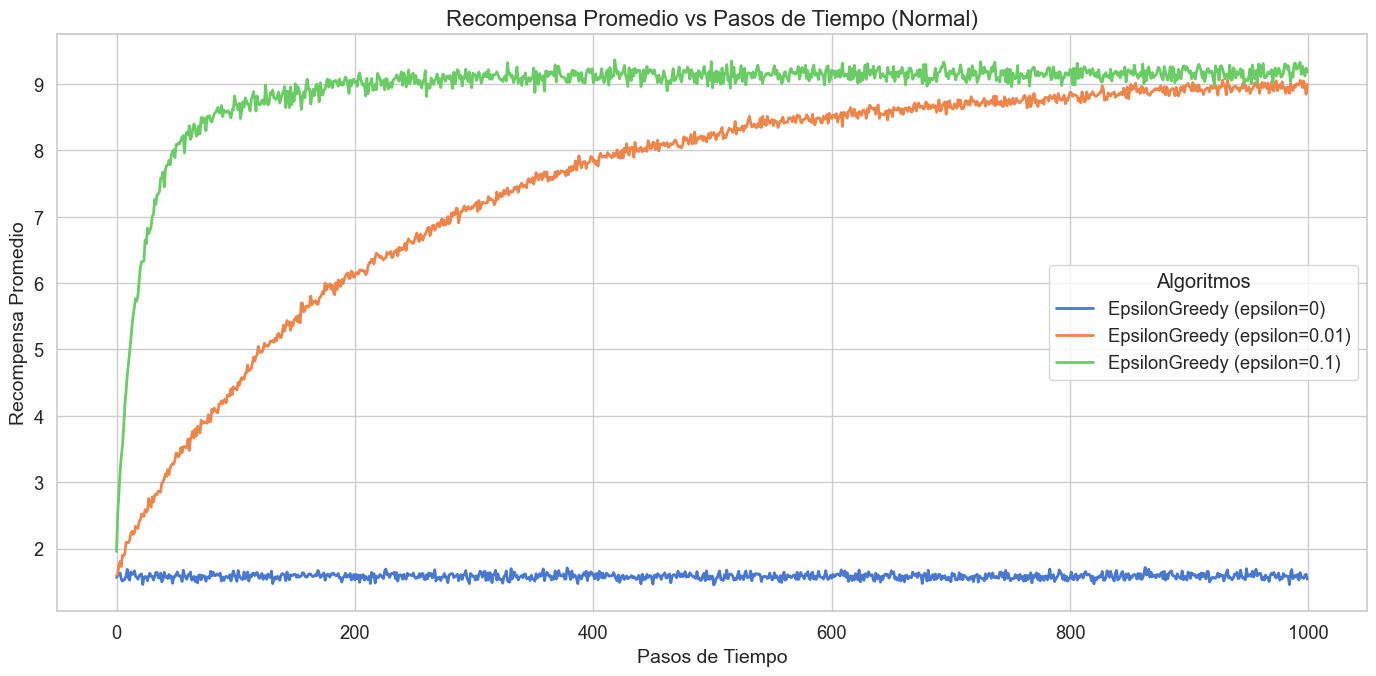

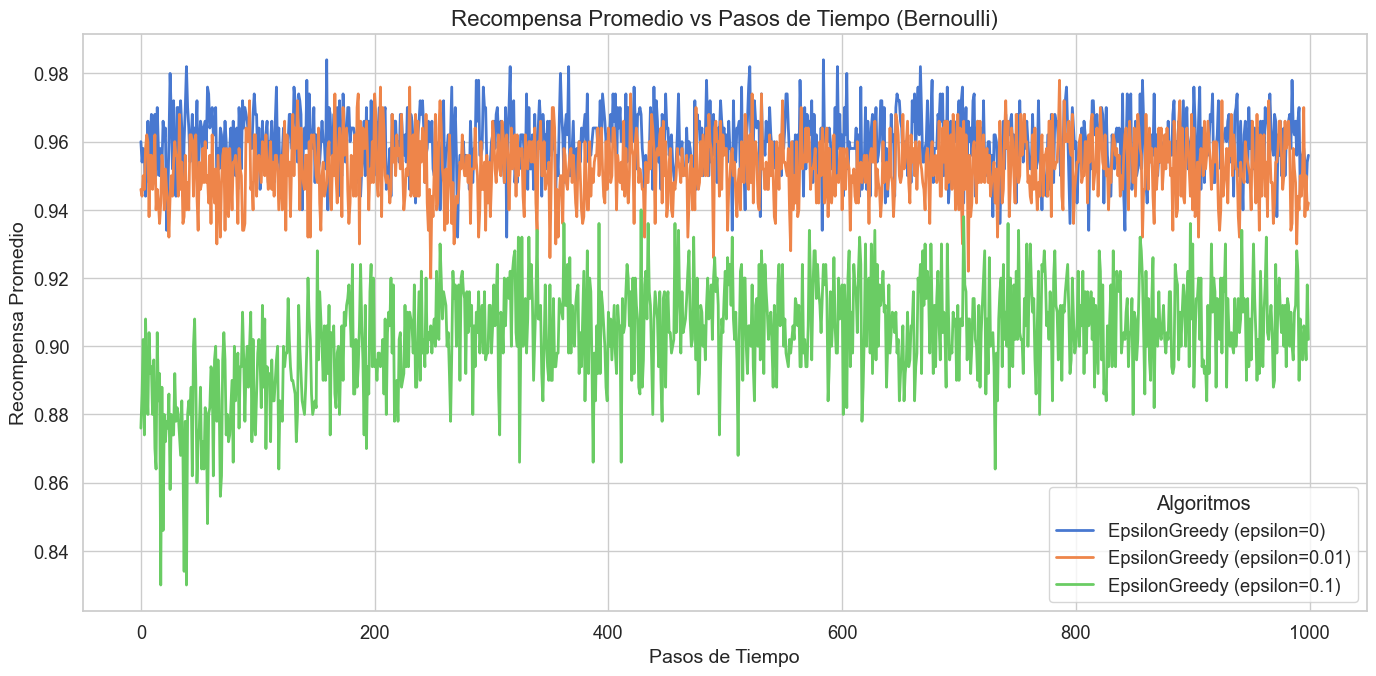

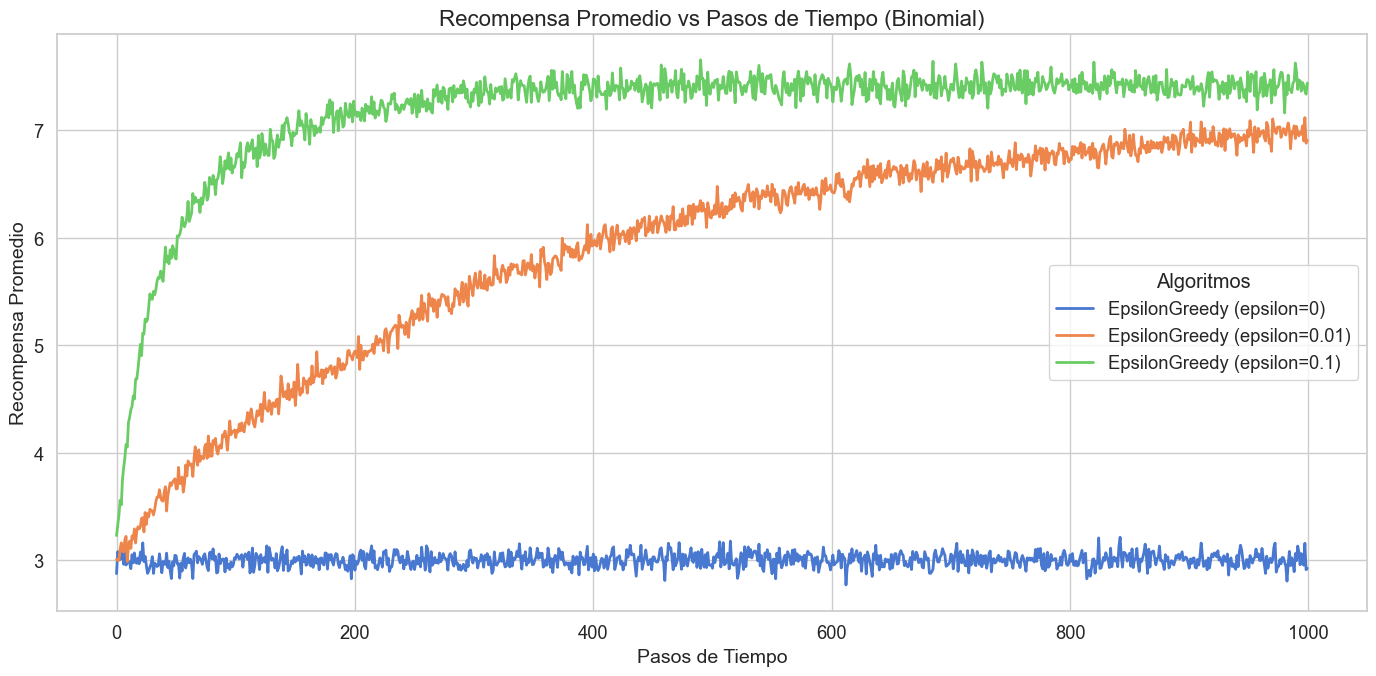

In [6]:
# Graficar los resultados
# Normal
plot_average_rewards(steps, rewards_normal, algorithms_plot, "Normal")

# Bernoulli
plot_average_rewards(steps, rewards_bernoulli, algorithms_plot, "Bernoulli")

# Binomial
plot_average_rewards(steps, rewards_binomial, algorithms_plot, "Binomial")


### Análisis detallado de la imagen

Estas tres imágenes muestran gráficos de líneas titulados **"Recompensa Promedio vs Pasos de Tiempo"**, donde se analiza el desempeño de diferentes estrategias del algoritmo **ε-Greedy** en un entorno de multi-armed bandit. En el eje **x** se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra la **recompensa promedio** obtenida por cada algoritmo. Cada gráfico corresponde a un tipo de distribución de probabilidad, en orden, normal, Bernoulli y binomial.


1. **Tres líneas de colores distintos representan diferentes valores de ε en el algoritmo ε-Greedy:**
   - **Azul (ε = 0):** Representa una estrategia completamente **explotadora**, es decir, que siempre elige la acción que ha dado la mejor recompensa hasta ahora sin explorar nuevas opciones.
   - **Naranja (ε = 0.01):** Representa una estrategia con una pequeña probabilidad del 1% de elegir una acción aleatoria (exploración).
   - **Verde (ε = 0.1):** Representa una estrategia con un 10% de probabilidad de explorar acciones aleatorias.

2. **Crecimiento de la recompensa promedio:**

   2.1. **Distribución normal:**
   - La línea **verde (ε=0.1)** alcanza rápidamente una recompensa promedio alta, lo que indica que la estrategia con mayor exploración aprende más rápido qué brazos del bandit son óptimos.
   - La línea **naranja (ε=0.01)** también muestra un crecimiento, pero más lento en comparación con ε=0.1.
   - La línea **azul (ε=0)** se mantiene en un nivel bajo de recompensa, lo que sugiere que no logra encontrar el mejor brazo porque no explora nuevas opciones.

   2.2. **Distribución Bernoulli:**
   - Una diferencia clave de esta gráfico respecto a los otros dos es que la recomepensa está en el rango [0,1].
   - Además, las diferencias entre brazos son más pequeñas.
   - La línea **verde (ε=0.1)** en este caso, ocurre lo contrario a las otras dos distribuciones, es el que menos recompensa obtiene.
   - La línea **naranja (ε=0.01)** tiene una recompensa similar al azul.
   - La línea **azul (ε=0)** es el que mejor resultado obtiene. Como las recompensas están acotadas en [0,1] y la varianza es menor, las diferencias entre brazos pueden ser pequeñas. Por eso resulta ser el mejor. Esto nos lleva a pensar que en entornos con recompensas acotadas y menor ruido, la explotación pura puede ser una opción a considerar.

   2.3. **Distribución binomial:**
   - En general, muy similar al primer gráfico.
   - La línea **verde (ε=0.1)** converge rápido y es el algoritmo que antes encuentra el brazo óptimo.
   - La línea **naranja (ε=0.01)** le cuesta encontrar el óptimo más que a ε=0.1 pero consigue alcanzar una recompensa similar.
   - La línea **azul (ε=0)** no consigue encontrar el brazo óptimo, debido a no explorar nuevas opciones, aún así, comparándolo con el resultado de la normal, obtiene mejores resultados. Debido a que la recompensa en este caso está en torno al número 3 y en la normal en torno al 1,5.

---

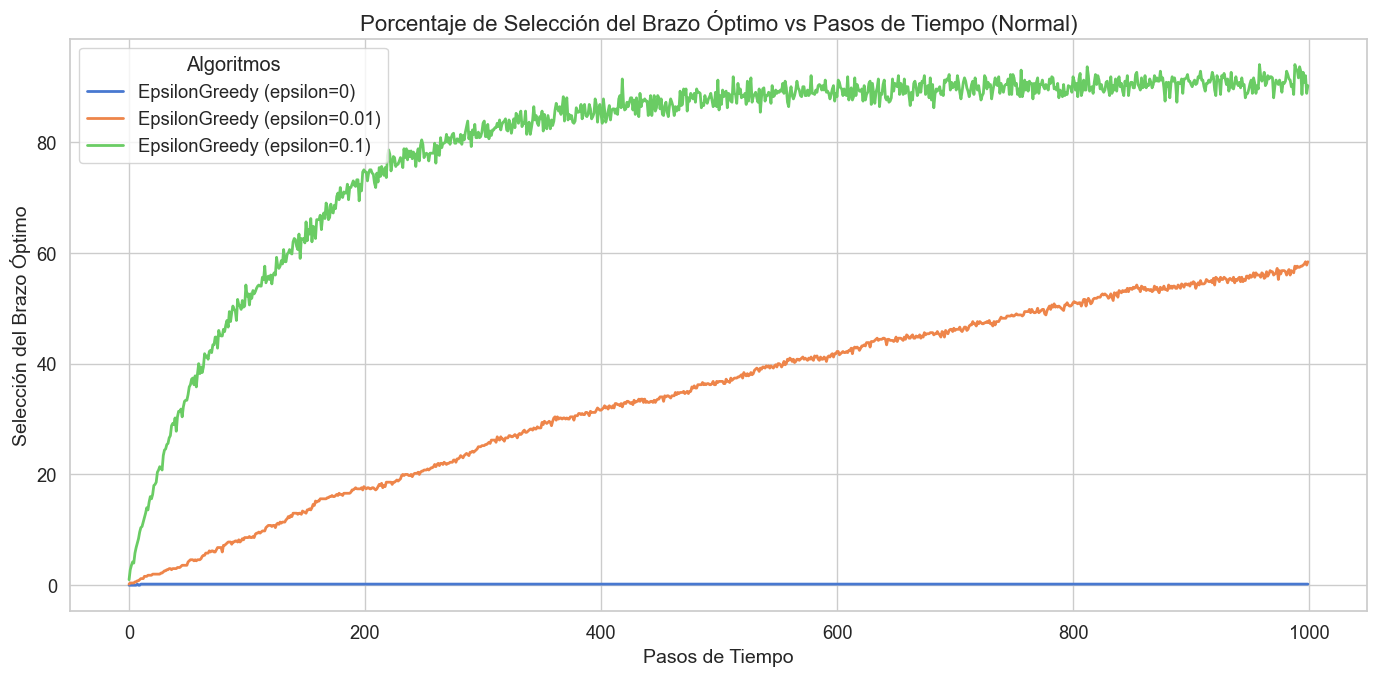

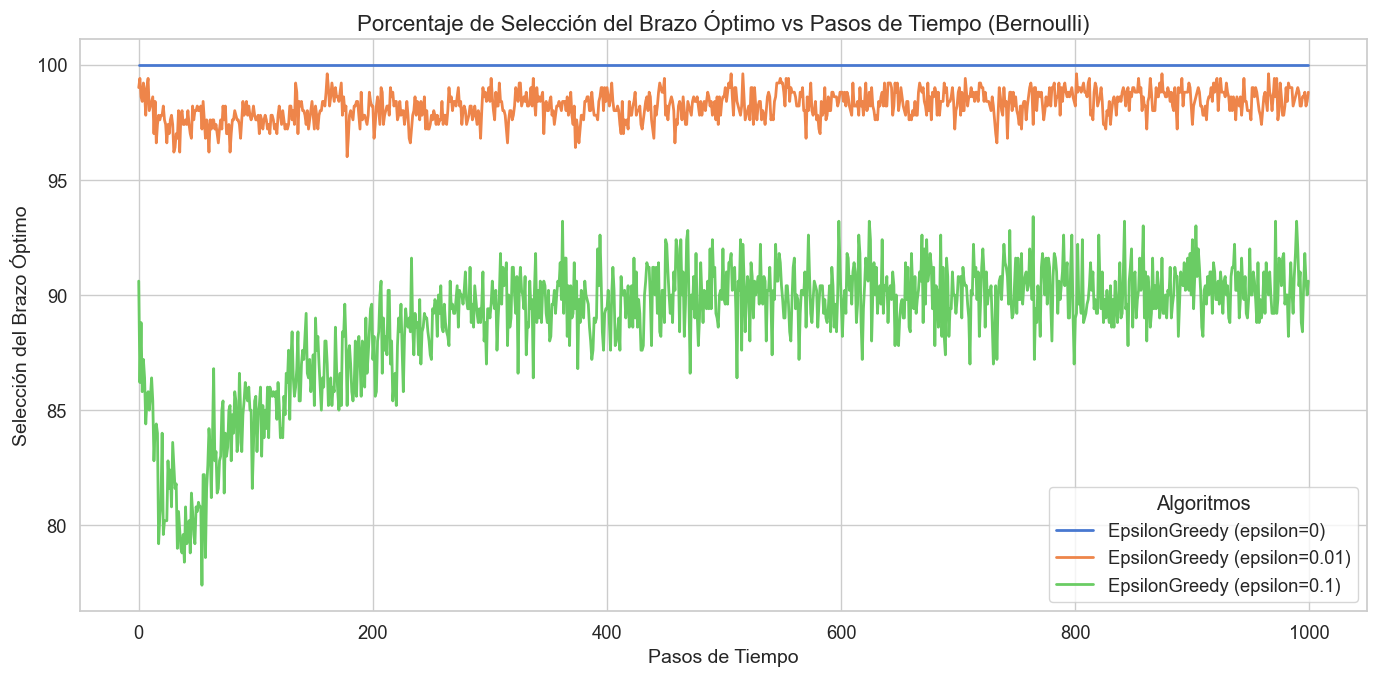

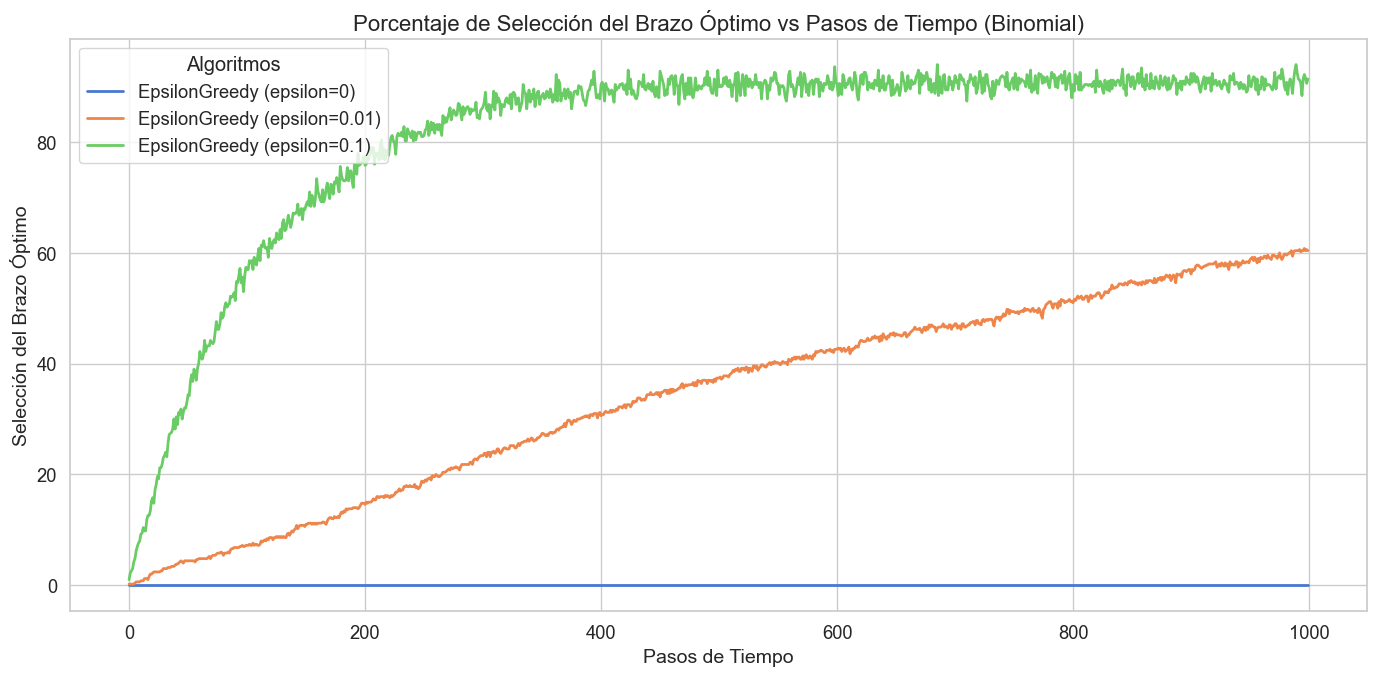

In [7]:
# Un plot para cada distribución
plot_optimal_selections(steps, optimal_normal, algorithms_plot, "Normal")
plot_optimal_selections(steps, optimal_bernoulli, algorithms_plot, "Bernoulli")
plot_optimal_selections(steps, optimal_binomial, algorithms_plot, "Binomial")

### Análisis detallado de la imagen

Estas tres imágenes muestran gráficos de líneas titulados **"Porcentaje de Selección del Brazo Óptimo vs Pasos de Tiempo"**, donde se analiza el desempeño de diferentes estrategias del algoritmo **ε-Greedy** en un entorno de multi-armed bandit. En el eje **x** se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra en qué **porcentaje** se ha **seleccionado el brazo óptimo** por cada algoritmo.


1. **Tres líneas de colores distintos representan diferentes valores de ε en el algoritmo ε-Greedy:**
   - De la misma forma que en el gráfico anterior.

2. **Porcentaje de Selección del Brazo Óptimo:**

   2.1. **Distribución normal:**
   - La línea **verde (ε=0.1)** es la que más brazos óptimos ha seleccionado, además de haberlos seleccionado desde el principio. Lo que indica que la estrategia con mayor exploración aprende más rápido qué brazos del bandit son óptimos.
   - La línea **naranja (ε=0.01)** también muestra un crecimiento, pero más lento en comparación con ε=0.1.
   - La línea **azul (ε=0)** no ha seleccionado el brazo óptimo en ningún momento. Como no explora nuevas opciones, nunca encontra el mejor brazo. A no ser que se hubiera seleccionado desde el principio por casualidad.

   2.2. **Distribución Bernoulli:**
   - La línea **verde (ε=0.1)** al contrario que en los otros dos gráficos, es que el peor desempeño tiene.
   - La línea **naranja (ε=0.01)** practicamente en todos los casos ha seleccionado el brazo óptimo. 
   - La línea **azul (ε=0)** lo que ha ocurrido aquí seguramente sea casualidad. Parece que desde el principio, el primer brazo seleccionado ha sido el óptimo, y como no hay exploración, ha seguido explotando (eligiendo) ese brazo, que casualmente era el óptimo, durante todos los instantes de tiempo. Por eso el porcentaje es del 100%.

   2.3. **Distribución binomial:**
   - Practicamente igual a los resultados obtenidos con la distribución normal, se sacan las mismas conclusiones. 
---

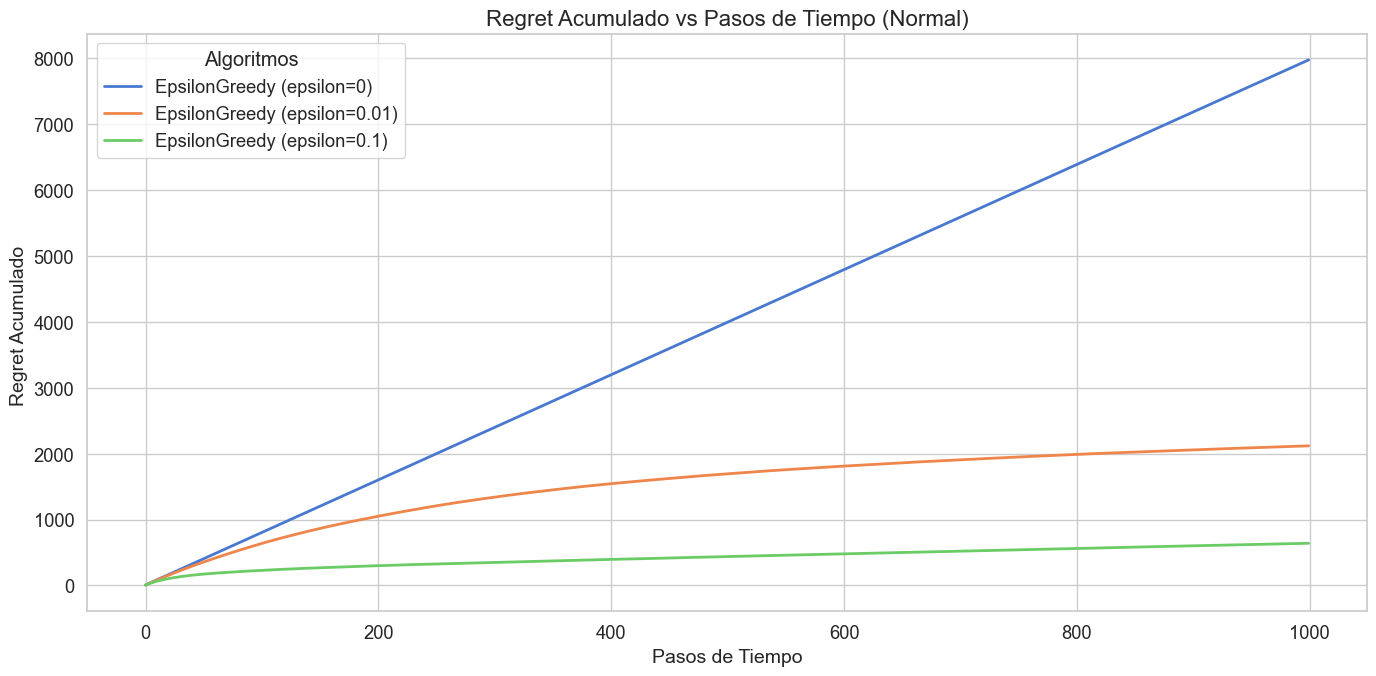

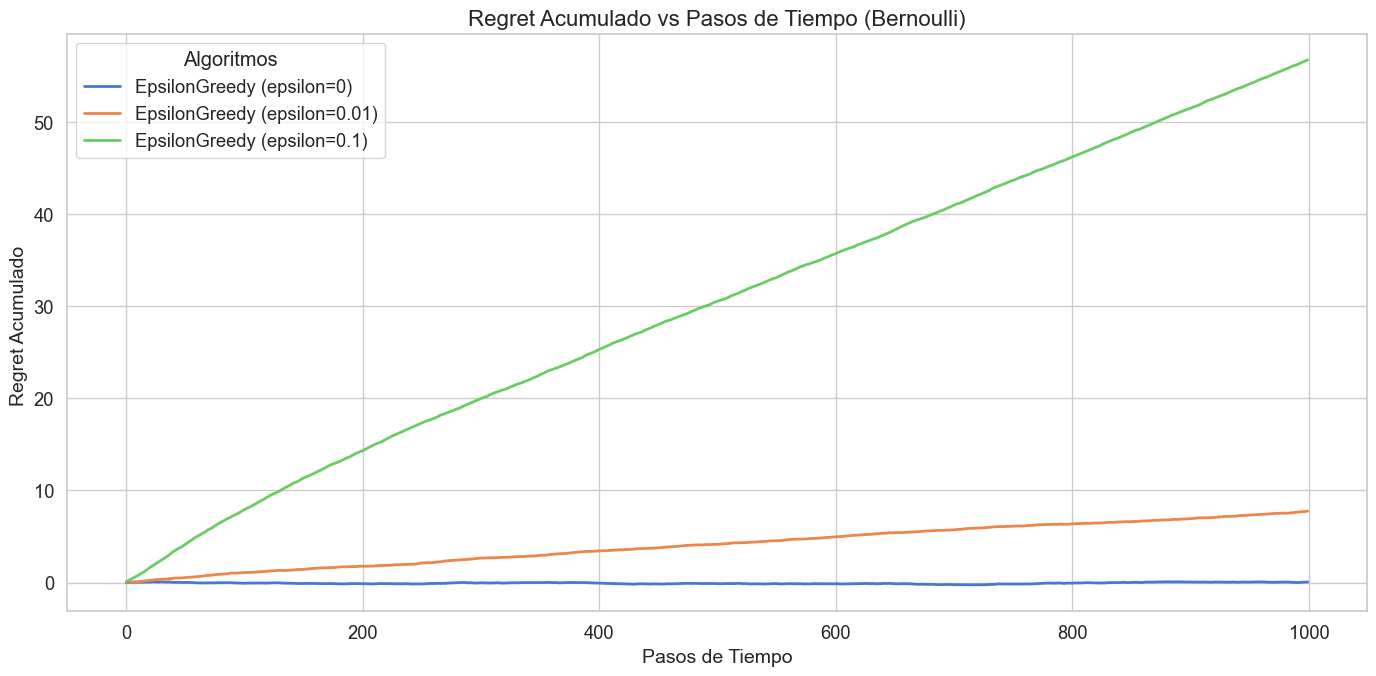

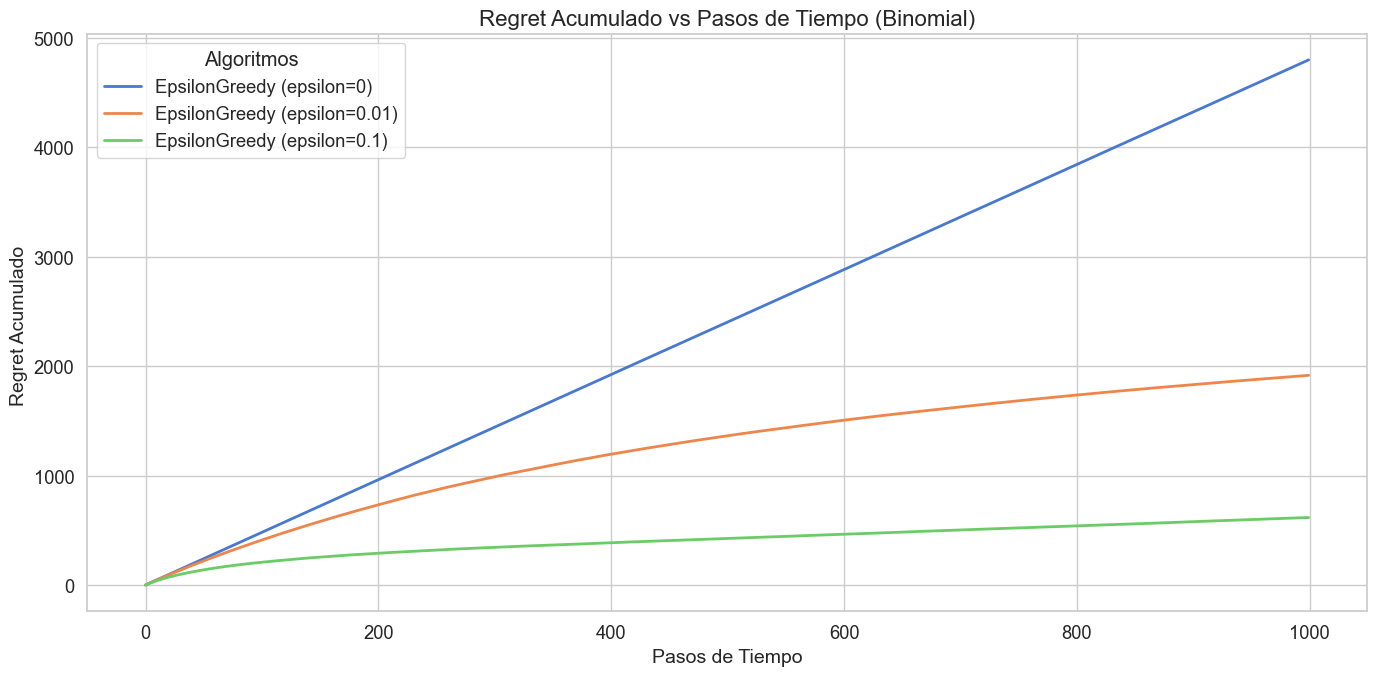

In [8]:
plot_regret(steps, regrets_normal, algorithms_plot, "Normal")
plot_regret(steps, regrets_bernoulli, algorithms_plot, "Bernoulli")
plot_regret(steps, regrets_binomial, algorithms_plot, "Binomial")

### Análisis detallado de la imagen

Estas tres imágenes muestran gráficos de líneas titulados **"Regret Acumulado vs Pasos de Tiempo"**, donde se analiza el desempeño de diferentes estrategias del algoritmo **ε-Greedy** en un entorno de multi-armed bandit. En el eje **x** se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra el  **arrepentiemiento acumulado** obtenido por cada algoritmo.


1. **Tres líneas de colores distintos representan diferentes valores de ε en el algoritmo ε-Greedy:**
   - De la misma forma que en los gráficos anteriores.

2. **Crecimiento del regret acumulado:**

   2.1. **Distribución normal:** 
   - La línea **verde (ε=0.1)** es el que menos arrepentimiento acumula. Esto se debe a que la diferencia entre el brazo óptimo de cada paso y el brazo seleccionado es menor, porque es el que más veces ha seleccionado el mejor brazo.
   - La línea **naranja (ε=0.01)** es un punto medio entre las otras dos líneas, ya que hay veces que sí selecciona el brazo óptimo, debido a tener algo de exploración y no puramente explotación. 
   - La línea **azul (ε=0)** acumula el mayor regret, por ser el que menos veces selecciona el mejor brazo. Esto se debe a que no explora.

   2.2. **Distribución Bernoulli:**
   - La línea **verde (ε=0.1)** al contrario que los gráficos de las otras dos distribuciones, es el que mayor arrepentimiento acumula.
   - La línea **naranja (ε=0.01)** tiene un buen desempeño. Un valor bajo de arrepentimiento.
   - La línea **azul (ε=0)** en este caso el arrepentimiento es 0, porque ya se ha visto en el anterior gráfico que explicaba el Porcentaje de Selección del Brazo Óptimo de este tipo de distribución, que se había seleccionado desde un principio el brazo óptimo. Por lo que no hay diferencia entre lo que hubiésemos conseguido seleccionando el brazo óptimo y lo conseguido con el brazo seleccionado, porque ambos son el mismo brazo.

   2.3. **Distribución binomial:**
   - Las 3 líneas crecen más lento que las líneas de la normal pero alcanzan valores muy similares al final de los 1000 pasos de tiempo. Menos en el caso de la línea azul, que en la normal llega hasta el valor 8000 y en este caso casi a 5000. Es decir, hay menos arrepentimiento siguiendo una distribución binomial, lo que implica una mejor elección del brazo óptimo.

---

Llamo a la función `build_arm_stats` para obtener las estadísticas de cada tipo de distribución y poder graficarlas

In [9]:
arm_stats_normal = build_arm_stats(bandit_normal, counts_normal, values_normal, algorithms_plot)
arm_stats_bernoulli = build_arm_stats(bandit_bernoulli, counts_bernoulli, values_bernoulli, algorithms_plot)
arm_stats_binomial = build_arm_stats(bandit_binomial, counts_binomial, values_binomial, algorithms_plot)

<Figure size 1400x700 with 0 Axes>

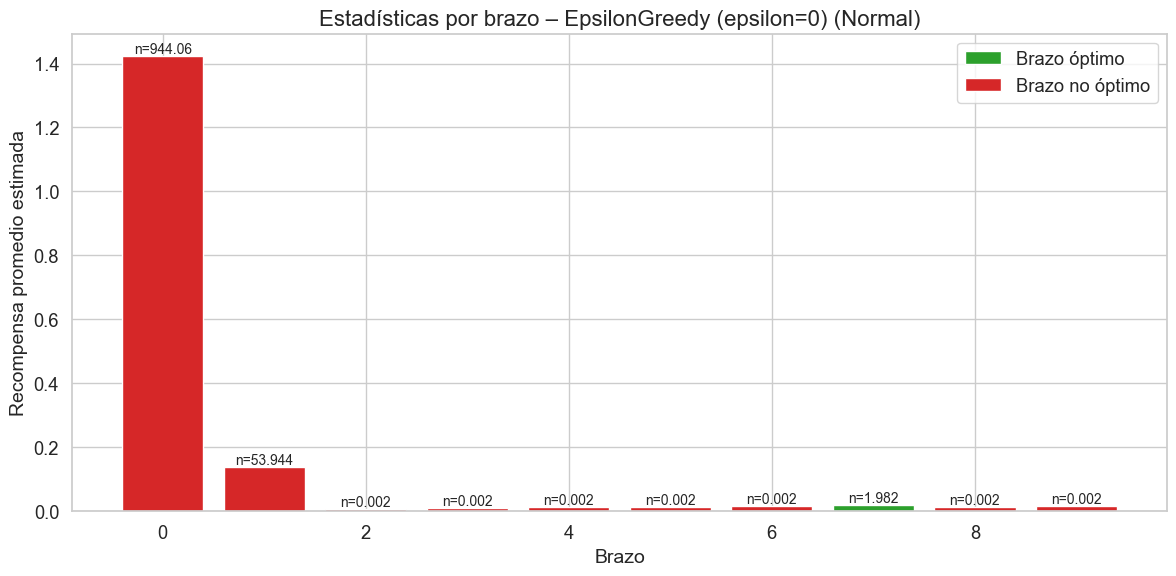

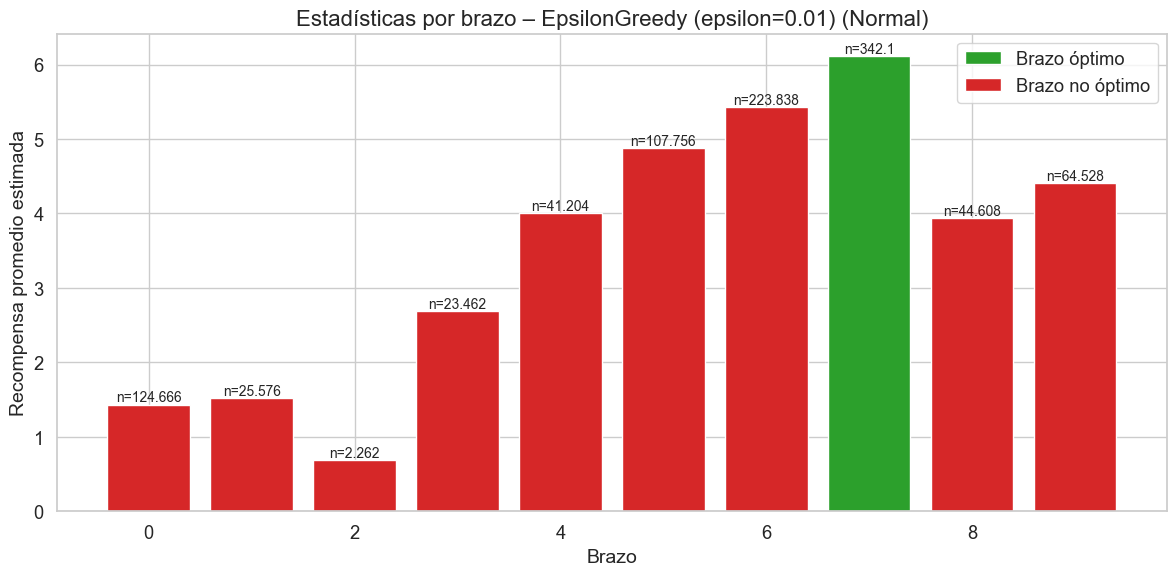

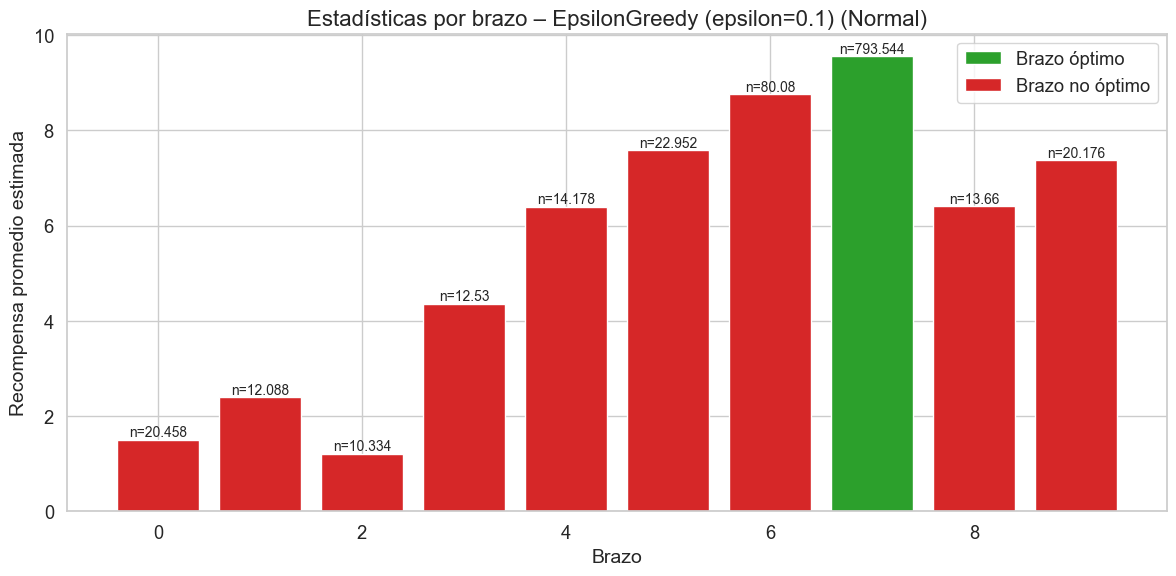

<Figure size 1400x700 with 0 Axes>

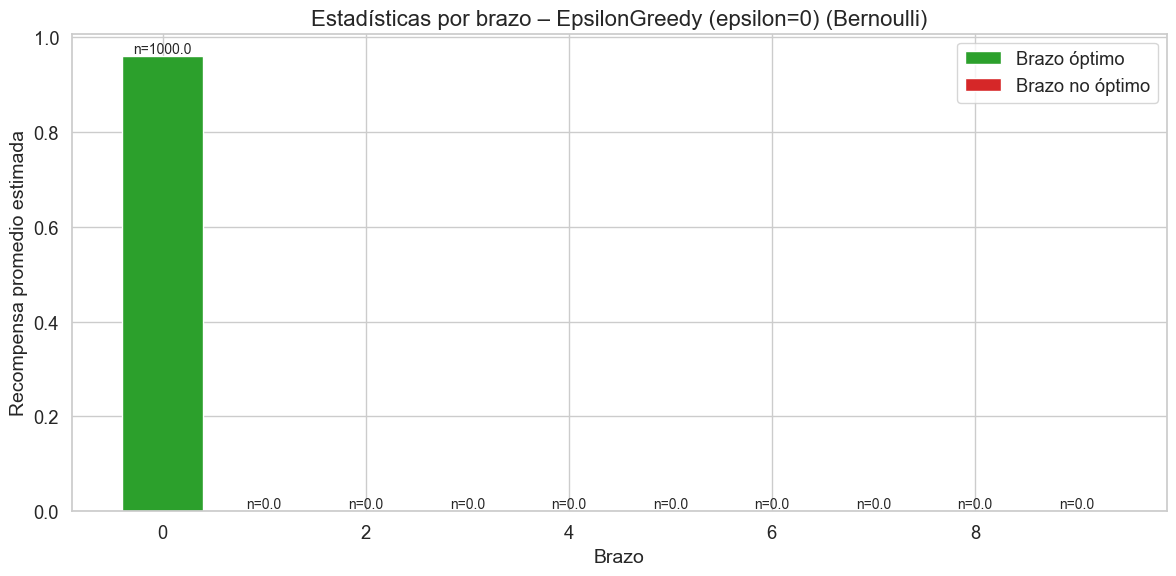

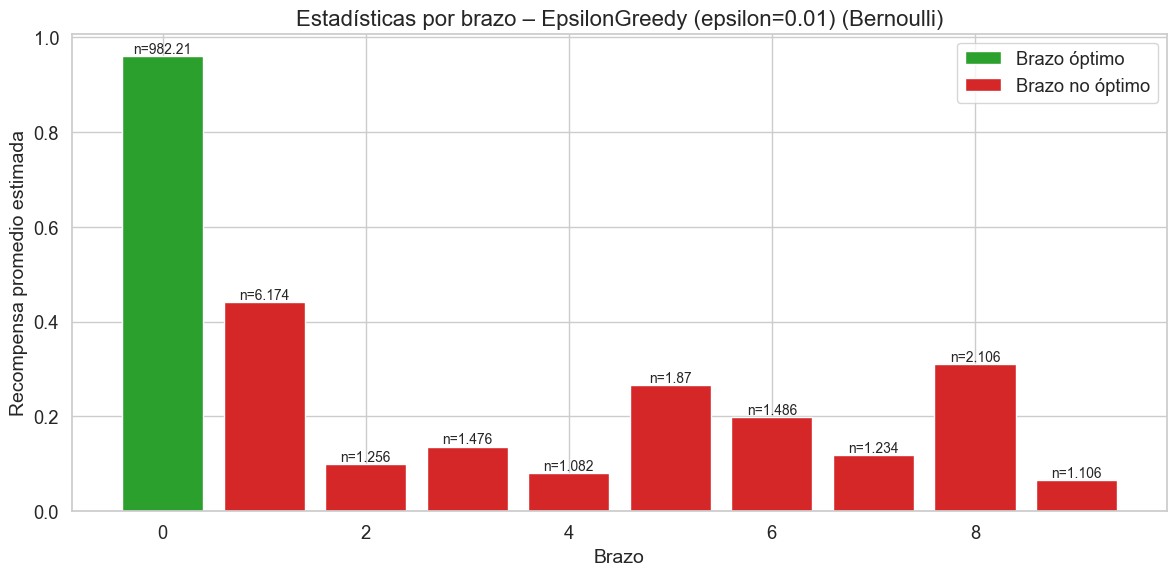

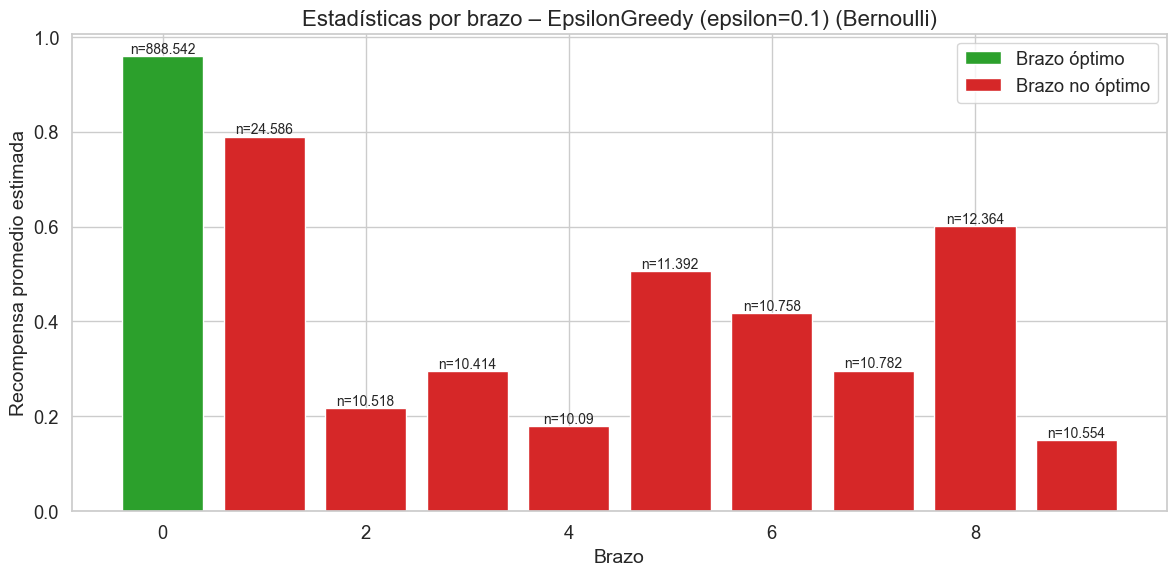

<Figure size 1400x700 with 0 Axes>

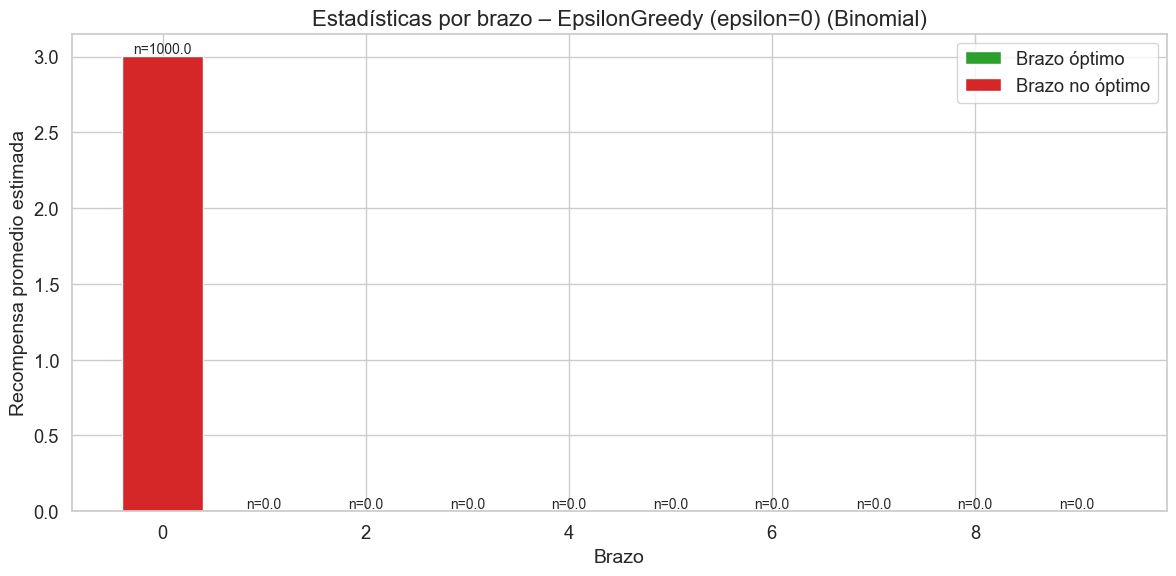

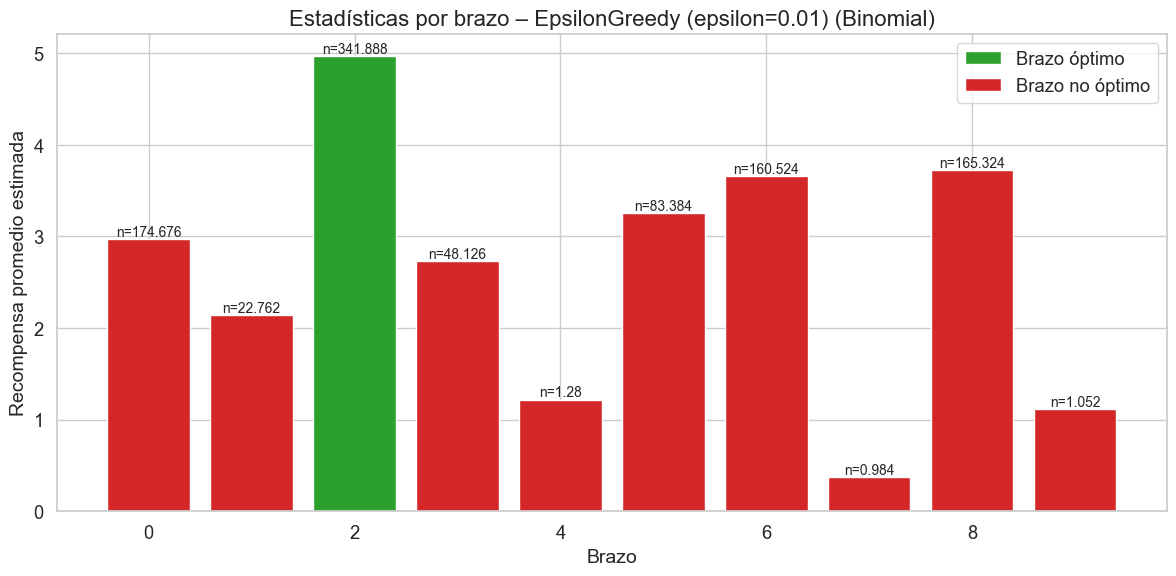

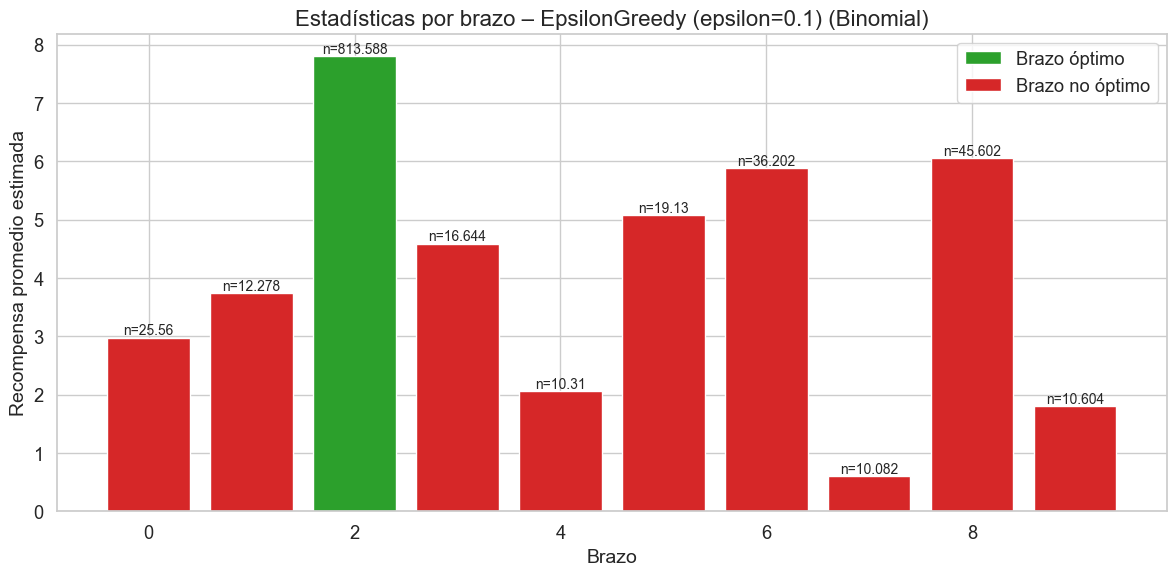

In [10]:
plot_arm_statistics(arm_stats_normal, algorithms_plot, "Normal")
plot_arm_statistics(arm_stats_bernoulli, algorithms_plot, "Bernoulli")
plot_arm_statistics(arm_stats_binomial, algorithms_plot, "Binomial")
#aquí hay un gráfico para cada valor de epsilon

### Análisis detallado de la imagen

Las imágenes muestran gráficos de líneas titulados **"Estadísticas por brazo"**, donde se analiza el desempeño de diferentes estrategias del algoritmo **ε-Greedy** en un entorno de multi-armed bandit. En el eje **x** se representan los **índices de los brazos**, mientras que en el eje **y** se muestra la  **recompensa promedio** obtenida pora ese brazo.

1. **Tres líneas de colores distintos representan diferentes valores de ε en el algoritmo ε-Greedy:**
   - De la misma forma que en los gráficos anteriores.

2. **Estadísticas por brazo:**

    2.1. **Distribución normal:** 
    - Gráfico 1 **(ε=0)**  como nunca ha seleccionado el brazo óptimo, por no existir exploración con ε=0, el brazo que más veces se ha seleccionado no es óptimo. De todas formas, como se ha hecho una modificación para que seleccione todos los brazos por lo menos una vez, sí que se ve la barra verde, aunque su selección ha sido mínima.
    - Gráfico 2 **(ε=0.01)** se seleccionan varios brazos, y el que aparece en verde es el brazo óptimo. Pero otros brazos se han seleccionado bastantes veces. No explota tanto el brazo óptimo.
    - Gráfico 3 **(ε=0.1)** en este caso el brazo óptimo tiene la mayoría de selecciones, no como en el caso anterior (que fueron al rededor de 350 y ahora casi 800), está claro que los demás brazos tienen pocas selecciones. Y que sí que aprende cuál es el brazo óptimo y lo explota.

    2.2. **Distribución Bernoulli:**
    - Gráfico 1 **(ε=0)** como se ha comprobado con anteriores gráficos, desde el princpio se ha seleccionado el brazo óptimo y se ha explotado durante toda la ejecución, por eso se observa en verde la única barra que hay en este gráfico.
    - Gráfico 2 **(ε=0.01)** sigue seleccionando en practicamente todas las ejecuciones el óptimo y explora muy poco. Explora tan poco que el resultado es muy similar al de ε=0.
    - Gráfico 3 **(ε=0.1)** en este caso, se reparten más las selecciones, pero tampoco tanto, porque selecciona el óptimo caso 900 veces de las 1000 ejecuciones. Hay brazos no óptimos que han sido seleccionados más veces debido a que con ε=0.1 hay mayor exploración.

   2.3. **Distribución binomial:**
    - Gráfico 1 **(ε=0)** debido a no existir la exploración, desde el princpio hasta el final no se ha seleccionado el brazo óptimo. Por eso, N=1000 tiene una barra en rojo. Similar al caso de la normal.
    - Gráfico 2 **(ε=0.01)** el brazo óptimo recibe muchas selecciones (en torno a 341), pero los demás brazos reciben significativamente menos (los que más, la mitad). Pero el algoritmo distingue antes el brazo óptimo.
    - Gráfico 3 **(ε=0.1)** el brazo óptimo domina, se selecciona más veces que en la normal.
    - Las barras están dentro de un rango más compacto y no hay fluctuaciones tan grandes. En la distribución binomial, hay menor varianza.

----

## Conclusiones

Hemos estudiado un  **experimento de toma de decisiones secuenciales**, modelado con un **Multi-Armed Bandit (MAB)**. Este problema es fundamental en el aprendizaje por refuerzo y la teoría de decisiones. La idea principal es que un agente debe aprender cuál es la mejor acción (brazo del bandit) a partir de la experiencia acumulada. Para este estudio nos hemos centrado solo en el estudio del algoritmo epsilon-greedy, llegando a las siguientes conclusiones a partir de los resultados obtenidos y la gráfica generada:

#### **1. Exploración vs Explotación**
El algoritmo **ε-Greedy** equilibra la exploración y la explotación:
- **Explotación (ε=0)**: Siempre elige la mejor opción conocida, pero si inicialmente se selecciona un brazo subóptimo, nunca descubrirá otras opciones más rentables.
- **Exploración (ε>0)**: Introduce aleatoriedad en la selección de acciones para descubrir nuevas opciones potencialmente mejores.

El gráfico confirma este comportamiento:
- **ε=0.1 (verde)** obtiene la mejor recompensa promedio a lo largo del tiempo porque explora lo suficiente como para encontrar rápidamente el mejor brazo.
- **ε=0.01 (naranja)** explora menos, por lo que tarda más en converger a una recompensa alta.
- **ε=0 (azul)** no explora en absoluto y queda atrapado en una recompensa subóptima.

#### **2. Convergencia de los algoritmos**
Los algoritmos con mayor exploración (ε=0.1) alcanzan una recompensa alta más rápido. Esto se debe a que:
- Al principio, el algoritmo **no tiene información suficiente** sobre cuál es el mejor brazo.
- Con el tiempo, al realizar exploraciones, descubre cuál es el mejor brazo y empieza a explotarlo más.
- Un **balance entre exploración y explotación** es clave para maximizar la recompensa a largo plazo.

#### **3. Normal vs Binomial vs Bernoulli**
- En general, los resultados de la normal y binomial son similares. No hay diferencias exageradas.
- Pero sí hay gran diferencia entre esas dos y Bernoulli. Además, hay que tener en cuenta que como este algoritmo ha seleccionado el brazo óptimo desde el principio, con ε=0 ha conseguido los mejores resultados, a pesar de no haber introducido nada de exploración.
- Comparando la normal y la binomial vemos que hay mayor varianza en los gráficos de la primera y más oscilaciones en las estimaciones. En cambio, en la binomial, es más estable, consiguiendo encontrar de forma más fácil el brazo óptimo.
- Como conclusión, esto nos deja claro que el comportamiento del algoritmo no depende solo de ε, sino también de la distribución estadística aplicada.


#### **4. Aplicaciones y conclusiones**
- En problemas de toma de decisiones **(ejemplo: recomendaciones, optimización de anuncios, medicina personalizada)**, una estrategia de exploración moderada como **ε=0.1** es más efectiva para encontrar la mejor opción rápidamente.
- **La falta de exploración (ε=0)** lleva a un desempeño deficiente, ya que el agente puede quedarse atrapado en una elección subóptima.

En conclusión, **el gráfico muestra cómo un nivel adecuado de exploración mejora significativamente el rendimiento del algoritmo en un entorno de aprendizaje por refuerzo**. 🚀

### **¿Cuál de todas las gráficas es la más relevante?**

Respondiendo a la pregunta. La gráfica más relevante es la del regret (arrepentimiento). Teniendo en cuenta que el arrepentimiento mide la diferencia entre la política óptima y la política elegida, es decir, mide cuánto mejor nos podría haber ido si hubiesemos seleccionado la mejor opción; esto nos da una información muy importante.

No consideramos más relevante las otras gráficas porque, por ejemplo, la recompensa promedio (definida en la función `plot_average_rewards`) puede ser parecida entre algoritmos: dos algoritmos pueden tener una recompensas promedio similares aunque uno se esté comportando mejor que otro, puede que tengan una gran diferencia en la cantidad de decisiones subóptimas que han tomado durante el proceso de aprendizaje.

En cambio, el arrepentimiento es más fiable. Penaliza explícitamente cada elección no óptima y refleja la eficiencia del algoritmo al identificar el mejor brazo